# Phase 6-T — Temporal Memory Persistence

This notebook extends Phase 6 from **single final-frame memory inference** to **short temporal observation windows**.

Phase 6 asked:

> Can one final black-hole image reveal what happened in the past?

Phase 6-T asks:

> How much more event identity and event timing become recoverable when the model sees a short video sequence instead of a single frame?

The experiment generates simulator-style temporal clips from the existing Phase 6 event histories. Each sample stores the last `CLIP_LENGTH` frames before the final observation. The model receives a tensor of shape:

```text
[B, T_clip, 1, H, W]
```

and predicts:

```text
event_type, event_age
```

The result is compared against the Phase 6 single-frame baseline.

In [1]:
# ================================================================
# 1. Imports and setup
# ================================================================

import os
import json
import math
import random
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.9.0+cu128
CUDA available: True


device(type='cuda')

In [2]:
# ================================================================
# 2. Configuration
# ================================================================

PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

GPU_SIMULATOR_PATH = PROJECT_ROOT / "physics_blackhole_demo.py"

# Existing Phase 6 single-frame dataset. Phase 6-T reuses its histories and metadata.
PHASE6_DATASET_DIR = DATA_ROOT / "dataset_phase6_memory_persistence"

# New Phase 6-T temporal dataset.
DATASET_DIR = DATA_ROOT / "dataset_phase6T_temporal_memory_persistence"
PHASE6T_DIR = OUTPUT_DIR / "phase6T_temporal_memory_persistence"
PHASE6_DIR = OUTPUT_DIR / "phase6_memory_persistence"

# Set True only when intentionally regenerating clips.
OVERWRITE_DATASET = True

SEED = 42
IMAGE_SIZE = 128
HISTORY_T = 160

# Temporal observation window.
# Try 8 first. Later you can repeat with 16 for a stronger temporal signal.
CLIP_LENGTH = 8

# Frames are sampled at the end of the history. STRIDE=1 means final 8 consecutive frames.
CLIP_STRIDE = 1

EVENT_AGES = [0, 5, 10, 20, 40, 60, 90, 120]
EVENT_TYPES = ["accretion_burst", "jet_eruption", "turbulence_spike", "spin_transition"]
EVENT_TO_INDEX = {name: i for i, name in enumerate(EVENT_TYPES)}
INDEX_TO_EVENT = {i: name for name, i in EVENT_TO_INDEX.items()}

TARGET_COLUMNS = ["mass", "spin", "accretion", "jet_power", "turbulence", "disk_luminosity"]

INPUT_MODE = "clean"  # options: "clean", "noisy"

BATCH_SIZE = 12
NUM_WORKERS = 0
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
NUM_EPOCHS = 45
LEARNING_RATE = 5e-4
EARLY_STOPPING_PATIENCE = 8

TYPE_LOSS_WEIGHT = 1.0
AGE_LOSS_WEIGHT = 0.75

NOISE_SIGMA_RANGE = (0.015, 0.11)
BLUR_SIGMA_RANGE = (0.0, 1.4)

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PHASE6T_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility controls.
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

try:
    torch.use_deterministic_algorithms(True)
    DETERMINISTIC_ALGORITHMS = True
except Exception as e:
    DETERMINISTIC_ALGORITHMS = False
    print("Warning: deterministic algorithms could not be fully enabled.")
    print(e)

SPLIT_GENERATOR = torch.Generator().manual_seed(SEED)
LOADER_GENERATOR = torch.Generator().manual_seed(SEED)

print("Project root:", PROJECT_ROOT.resolve())
print("GPU simulator:", GPU_SIMULATOR_PATH.resolve())
print("GPU simulator exists:", GPU_SIMULATOR_PATH.exists())
print("Phase 6 source dataset:", PHASE6_DATASET_DIR.resolve())
print("Phase 6-T dataset:", DATASET_DIR.resolve())
print("Phase 6-T outputs:", PHASE6T_DIR.resolve())
print("Input mode:", INPUT_MODE)
print("Clip length:", CLIP_LENGTH)
print("Clip stride:", CLIP_STRIDE)
print("Deterministic algorithms:", DETERMINISTIC_ALGORITHMS)

Project root: /home/marwa/files/phase1_blackhole_generator
GPU simulator: /home/marwa/files/phase1_blackhole_generator/physics_blackhole_demo.py
GPU simulator exists: True
Phase 6 source dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence
Phase 6-T dataset: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6T_temporal_memory_persistence
Phase 6-T outputs: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence
Input mode: clean
Clip length: 8
Clip stride: 1
Deterministic algorithms: True


In [3]:
# ================================================================
# 3. Verify Phase 6 source dataset and simulator
# ================================================================

if not GPU_SIMULATOR_PATH.exists():
    raise FileNotFoundError(
        f"Missing GPU simulator: {GPU_SIMULATOR_PATH}. Put physics_blackhole_demo.py in PROJECT_ROOT."
    )

if not PHASE6_DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Missing Phase 6 dataset: {PHASE6_DATASET_DIR}. Run Phase 6 first."
    )

for required in ["params_table.csv", "manifest.json"]:
    path = PHASE6_DATASET_DIR / required
    if not path.exists():
        raise FileNotFoundError(f"Missing required Phase 6 file: {path}")

for sd in ["clean", "noisy", "history", "metadata"]:
    path = PHASE6_DATASET_DIR / sd
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 6 subfolder: {path}")

sim_source = GPU_SIMULATOR_PATH.read_bytes()
simulator_sha256 = hashlib.sha256(sim_source).hexdigest()
sim_text = sim_source.decode("utf-8", errors="ignore")

print("Simulator SHA256:", simulator_sha256)
for token in ["u_mass", "u_spin", "u_accretion", "u_time"]:
    print(f"contains {token}:", token in sim_text)

with open(PHASE6_DATASET_DIR / "manifest.json", "r") as f:
    phase6_manifest = json.load(f)

params_df = pd.read_csv(PHASE6_DATASET_DIR / "params_table.csv")

print("Phase 6 samples:", len(params_df))
print("Phase 6 event types:", phase6_manifest.get("event_types"))
print("Phase 6 event ages:", phase6_manifest.get("event_ages"))
display(params_df.head())

Simulator SHA256: 41e00c206e5f47711d06305ba4aff5aaa65802f846682288c5f5d78aa1a2ac2a
contains u_mass: True
contains u_spin: True
contains u_accretion: True
contains u_time: True
Phase 6 samples: 1120
Phase 6 event types: ['accretion_burst', 'jet_eruption', 'turbulence_spike', 'spin_transition']
Phase 6 event ages: [0, 5, 10, 20, 40, 60, 90, 120]


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,jet_power,turbulence,disk_luminosity,event_profile_recent,event_age,event_center,sample_id,sample_index,event_type,event_type_index
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,0.368827,0.270658,0.710300,0.294393,0,159,p6_00001,1,accretion_burst,0
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,0.560022,0.191374,0.835475,0.301307,0,159,p6_00002,2,accretion_burst,0
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,0.397768,0.601976,0.665426,0.365520,0,159,p6_00003,3,accretion_burst,0
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,0.421727,0.326509,1.326374,0.307380,0,159,p6_00004,4,accretion_burst,0
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,0.703728,0.392102,1.198455,0.490090,0,159,p6_00005,5,accretion_burst,0


In [4]:
# ================================================================
# 4. Recreate Phase 6 simulator-compatible renderer
# ================================================================

_RENDER_CACHE = {}


def get_grid(size, device):
    key = (size, str(device))
    if key in _RENDER_CACHE:
        return _RENDER_CACHE[key]
    axis = torch.linspace(-1.0, 1.0, size, device=device)
    y, x = torch.meshgrid(axis, axis, indexing="ij")
    r = torch.sqrt(x * x + y * y + 1e-8)
    phi = torch.atan2(y, x)
    _RENDER_CACHE[key] = (x, y, r, phi)
    return x, y, r, phi


def summary_at_frame(history_df, frame_index, window=18):
    frame_index = int(frame_index)
    start = max(0, frame_index - window + 1)
    recent = history_df.iloc[start:frame_index + 1]
    current = history_df.iloc[frame_index]

    return {
        "mass": float(current["mass"]),
        "spin": float(recent["spin"].mean()),
        "spin_final": float(current["spin"]),
        "accretion": float(recent["accretion"].mean()),
        "jet_power": float(recent["jet_power"].mean()),
        "turbulence": float(recent["turbulence"].mean()),
        "disk_luminosity": float(recent["disk_luminosity"].mean()),
        "event_profile_recent": float(recent["event_profile"].mean()),
        "event_age": float(current["event_age"]),
        "event_center": float(current["event_center"]),
        "frame_index": frame_index,
    }


def render_simulator_frame_at(params_row, history_df, frame_index, size=128, device=DEVICE):
    h = summary_at_frame(history_df, frame_index)
    x, y, r, phi = get_grid(size, device)

    mass = torch.tensor(h["mass"], device=device)
    spin = torch.tensor(h["spin"], device=device)
    spin_final = torch.tensor(h["spin_final"], device=device)
    acc = torch.tensor(h["accretion"], device=device)
    jet_power = torch.tensor(h["jet_power"], device=device)
    turb_level = torch.tensor(h["turbulence"], device=device)
    lum = torch.tensor(h["disk_luminosity"], device=device)
    event_recent = torch.tensor(h["event_profile_recent"], device=device)

    observer_angle = torch.tensor(float(params_row["observer_angle"]) * math.pi / 180.0, device=device)
    yaw = torch.tensor(float(params_row["camera_yaw"]), device=device)

    cos_i = torch.clamp(torch.cos(observer_angle), min=0.30)
    x_cam = x * torch.cos(yaw) - y * torch.sin(yaw)
    y_cam = x * torch.sin(yaw) + y * torch.cos(yaw)
    y_inc = y_cam / cos_i

    spin_shift = 0.035 * (spin_final - 0.5)
    x_shift = x_cam - spin_shift
    r_inc = torch.sqrt(x_shift * x_shift + y_inc * y_inc + 1e-8)
    phi_inc = torch.atan2(y_inc, x_shift)

    shadow_radius = 0.095 + 0.010 * (mass / 10.0)
    shadow_edge = 0.014 + 0.006 * jet_power
    shadow_mask = torch.clamp((r - shadow_radius) / shadow_edge, 0.0, 1.0)

    warp = 0.018 * spin * torch.sin(phi_inc - spin * math.pi)
    warp += 0.012 * turb_level * torch.sin(3.0 * phi_inc + spin * 2.0 * math.pi)
    ring_radius = 0.175 + 0.012 * (mass / 10.0 - 1.0) + warp
    ring_width = 0.025 + 0.010 * jet_power
    ring = torch.exp(-0.5 * ((r_inc - ring_radius) / ring_width) ** 2)
    ring *= 1.0 + (0.40 + 0.55 * spin) * torch.sin(observer_angle) * torch.cos(phi_inc - spin * math.pi)

    inner = 0.16 + 0.010 * (mass / 10.0 - 1.0)
    outer = 0.76 + 0.08 * lum
    disk_mask = torch.sigmoid((r_inc - inner) / 0.018) * torch.sigmoid((outer - r_inc) / 0.04)
    radial = torch.exp(-2.6 * torch.clamp((r_inc - inner) / (outer - inner + 1e-6), 0.0, 2.0))
    disk = disk_mask * radial * (0.45 + 0.65 * lum) * (0.55 + 0.45 * acc)

    texture = torch.zeros_like(r)
    for k in range(1, 9):
        phase = 0.8 * k + 0.13 * h["event_center"] + 0.07 * frame_index
        texture += torch.sin((2.0 + k * 1.7) * phi_inc + phase) * torch.cos((3.0 + k * 0.85) * r_inc * math.pi + phase)
    texture = texture / 8.0
    disk = disk * (1.0 + (0.20 + 0.35 * turb_level) * texture)

    clumps = torch.zeros_like(r)
    for k in range(4):
        angle = 1.3 * k + 0.07 * h["event_center"] + 0.05 * frame_index + float(spin.detach().cpu())
        rr = 0.25 + 0.09 * k
        dphi = torch.atan2(torch.sin(phi_inc - angle), torch.cos(phi_inc - angle))
        clumps += torch.exp(-0.5 * ((r_inc - rr) / 0.045) ** 2) * torch.exp(-0.5 * (dphi / 0.23) ** 2)
    disk = disk + 0.22 * torch.clamp(0.30 * turb_level + 0.75 * event_recent, 0.0, 1.4) * clumps * disk_mask

    tilt = (spin - 0.5) * 0.40 + yaw * 0.25
    x_rot = x * torch.cos(tilt) - y * torch.sin(tilt)
    y_rot = x * torch.sin(tilt) + y * torch.cos(tilt)
    jet_width = 0.035 + 0.035 * torch.clamp(jet_power, 0.0, 1.5)
    jet_len = 0.42 + 0.26 * torch.clamp(jet_power, 0.0, 1.5)
    upper = torch.exp(-0.5 * (x_rot / jet_width) ** 2) * torch.exp(-torch.clamp(y_rot, min=0.0) / jet_len) * (y_rot > 0.14).float()
    lower = torch.exp(-0.5 * (x_rot / (jet_width * 1.15)) ** 2) * torch.exp(-torch.clamp(-y_rot, min=0.0) / (jet_len * 0.9)) * (y_rot < -0.14).float()
    jet = (upper + 0.75 * lower) * (0.15 + 0.75 * jet_power) * (0.35 + 0.65 * torch.sin(observer_angle))

    glow = torch.exp(-((r_inc / (0.55 + 0.12 * lum)) ** 2)) * (0.06 + 0.16 * lum)
    image = (0.74 * disk + 0.92 * ring + 0.55 * jet + glow) * shadow_mask
    image = torch.clamp(image, min=0.0)
    image = image / (image.max() + 1e-6)
    return torch.clamp(image, 0.0, 1.0).detach().float().cpu().numpy()


def gaussian_blur_numpy(image, sigma):
    if sigma <= 1e-8:
        return image.astype(np.float32)
    radius = int(max(1, round(3 * sigma)))
    xs = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (xs / sigma) ** 2)
    kernel = kernel / kernel.sum()
    temp = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 0, image)
    out = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), 1, temp)
    return out.astype(np.float32)


def corrupt_frame(clean, noise_sigma, blur_sigma, rng):
    image = gaussian_blur_numpy(clean.astype(np.float32), float(blur_sigma))
    image += rng.normal(0.0, float(noise_sigma), image.shape).astype(np.float32)
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def save_npz_clip(arr, path):
    arr = np.asarray(arr, dtype=np.float32)
    np.savez_compressed(path, clip=arr)


def load_npz_clip(path):
    with np.load(path) as data:
        return data["clip"].astype(np.float32)

In [5]:
# ================================================================
# 5. Prepare Phase 6-T output folders
# ================================================================

subdirs = ["clips_clean", "clips_noisy", "metadata", "history"]

existing_files = []
if DATASET_DIR.exists():
    existing_files = [p for p in DATASET_DIR.glob("**/*") if p.is_file()]

if existing_files:
    print(f"Existing Phase 6-T dataset detected with {len(existing_files)} files.")
    if OVERWRITE_DATASET:
        print("OVERWRITE_DATASET=True: removing old Phase 6-T dataset.")
        shutil.rmtree(DATASET_DIR)
    else:
        print("OVERWRITE_DATASET=False: keeping existing Phase 6-T dataset.")

for sd in subdirs:
    (DATASET_DIR / sd).mkdir(parents=True, exist_ok=True)

print("Phase 6-T folders ready:")
for sd in subdirs:
    print(sd, len(list((DATASET_DIR / sd).glob("*"))))

Phase 6-T folders ready:
clips_clean 0
clips_noisy 0
metadata 0
history 0


In [6]:
# ================================================================
# 6. Generate temporal clip dataset
# ================================================================

rows = []

if (DATASET_DIR / "params_table.csv").exists() and not OVERWRITE_DATASET:
    print("Loading existing Phase 6-T params table.")
    phase6t_params_df = pd.read_csv(DATASET_DIR / "params_table.csv")
else:
    for idx, row in params_df.iterrows():
        sample_id = str(row["sample_id"])
        history_path = PHASE6_DATASET_DIR / "history" / f"{sample_id}.csv"
        history_df = pd.read_csv(history_path)

        final_frame = HISTORY_T - 1
        frame_indices = [final_frame - (CLIP_LENGTH - 1 - k) * CLIP_STRIDE for k in range(CLIP_LENGTH)]
        frame_indices = [int(max(0, min(HISTORY_T - 1, t))) for t in frame_indices]

        clean_frames = []
        noisy_frames = []
        rng = np.random.default_rng(SEED + int(row["sample_index"]) * 31)

        for frame_idx in frame_indices:
            clean = render_simulator_frame_at(row, history_df, frame_idx, IMAGE_SIZE, DEVICE)
            noisy = corrupt_frame(clean, row["noise_sigma"], row["blur_sigma"], rng)
            clean_frames.append(clean)
            noisy_frames.append(noisy)

        clean_clip = np.stack(clean_frames, axis=0).astype(np.float32)  # [T,H,W]
        noisy_clip = np.stack(noisy_frames, axis=0).astype(np.float32)

        save_npz_clip(clean_clip, DATASET_DIR / "clips_clean" / f"{sample_id}.npz")
        save_npz_clip(noisy_clip, DATASET_DIR / "clips_noisy" / f"{sample_id}_noisy.npz")
        history_df.to_csv(DATASET_DIR / "history" / f"{sample_id}.csv", index=False)

        metadata = {
            "sample_id": sample_id,
            "source_phase6_dataset": str(PHASE6_DATASET_DIR),
            "event_type": row["event_type"],
            "event_type_index": int(row["event_type_index"]),
            "event_age": float(row["event_age"]),
            "event_center": int(row["event_center"]),
            "clip_length": CLIP_LENGTH,
            "clip_stride": CLIP_STRIDE,
            "frame_indices": frame_indices,
            "gpu_simulator_path": str(GPU_SIMULATOR_PATH),
            "gpu_simulator_sha256": simulator_sha256,
        }

        with open(DATASET_DIR / "metadata" / f"{sample_id}.json", "w") as f:
            json.dump(metadata, f, indent=2)

        out_row = row.to_dict()
        out_row.update({
            "clip_length": CLIP_LENGTH,
            "clip_stride": CLIP_STRIDE,
            "frame_start": frame_indices[0],
            "frame_end": frame_indices[-1],
        })
        rows.append(out_row)

        if (idx + 1) % 100 == 0:
            print(f"Generated clips {idx + 1}/{len(params_df)}")

    phase6t_params_df = pd.DataFrame(rows)
    phase6t_params_df.to_csv(DATASET_DIR / "params_table.csv", index=False)

print("Phase 6-T samples:", len(phase6t_params_df))
display(phase6t_params_df.head())

Generated clips 100/1120
Generated clips 200/1120
Generated clips 300/1120
Generated clips 400/1120
Generated clips 500/1120
Generated clips 600/1120
Generated clips 700/1120
Generated clips 800/1120
Generated clips 900/1120
Generated clips 1000/1120
Generated clips 1100/1120
Phase 6-T samples: 1120


,mass,spin_base,accretion_base,jet_base,turbulence_base,luminosity_base,observer_angle,camera_yaw,camera_pitch,camera_distance,...,event_age,event_center,sample_id,sample_index,event_type,event_type_index,clip_length,clip_stride,frame_start,frame_end
0,10.701978,0.773896,0.478638,0.326458,0.230384,0.486240,0.436469,0.330855,-0.153351,6.836295,...,0,159,p6_00001,1,accretion_burst,0,8,1,152,159
1,12.450652,0.907840,1.100640,0.532531,0.154680,0.612558,42.129864,0.326721,-0.099558,5.374476,...,0,159,p6_00002,2,accretion_burst,0,8,1,152,159
2,13.883923,0.536270,0.855293,0.360879,0.564212,0.398242,72.902503,-0.041671,0.143898,4.581893,...,0,159,p6_00003,3,accretion_burst,0,8,1,152,159
3,13.443942,0.510448,1.133776,0.401334,0.267895,1.094901,5.160053,0.141838,-0.155945,5.614198,...,0,159,p6_00004,4,accretion_burst,0,8,1,152,159
4,6.499732,0.256092,0.679266,0.646034,0.321586,0.847696,71.984299,0.219969,-0.079398,4.618977,...,0,159,p6_00005,5,accretion_burst,0,8,1,152,159


In [7]:
# ================================================================
# 7. Manifest and integrity checks
# ================================================================

manifest = {
    "dataset_name": "phase6T_temporal_memory_persistence_dataset",
    "version": "6T.0",
    "n_samples": int(len(phase6t_params_df)),
    "image_size": IMAGE_SIZE,
    "history_T": HISTORY_T,
    "clip_length": CLIP_LENGTH,
    "clip_stride": CLIP_STRIDE,
    "input_modes": ["clean", "noisy"],
    "seed": SEED,
    "event_types": EVENT_TYPES,
    "event_ages": EVENT_AGES,
    "source_phase6_dataset": str(PHASE6_DATASET_DIR),
    "gpu_simulator_path": str(GPU_SIMULATOR_PATH),
    "gpu_simulator_sha256": simulator_sha256,
    "scientific_question": "How much more memory is recoverable from temporal observations than from one final frame?",
}

with open(DATASET_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

for sd in ["clips_clean", "clips_noisy", "metadata", "history"]:
    files = list((DATASET_DIR / sd).glob("*"))
    print(sd, len(files))
    assert len(files) == len(phase6t_params_df), f"Unexpected file count in {sd}"

example_sid = str(phase6t_params_df.iloc[0]["sample_id"])
example_clip = load_npz_clip(DATASET_DIR / "clips_clean" / f"{example_sid}.npz")
assert example_clip.shape == (CLIP_LENGTH, IMAGE_SIZE, IMAGE_SIZE), example_clip.shape

print("Integrity checks passed.")
print("Example clip shape:", example_clip.shape)

clips_clean 1120
clips_noisy 1120
metadata 1120
history 1120
Integrity checks passed.
Example clip shape: (8, 128, 128)


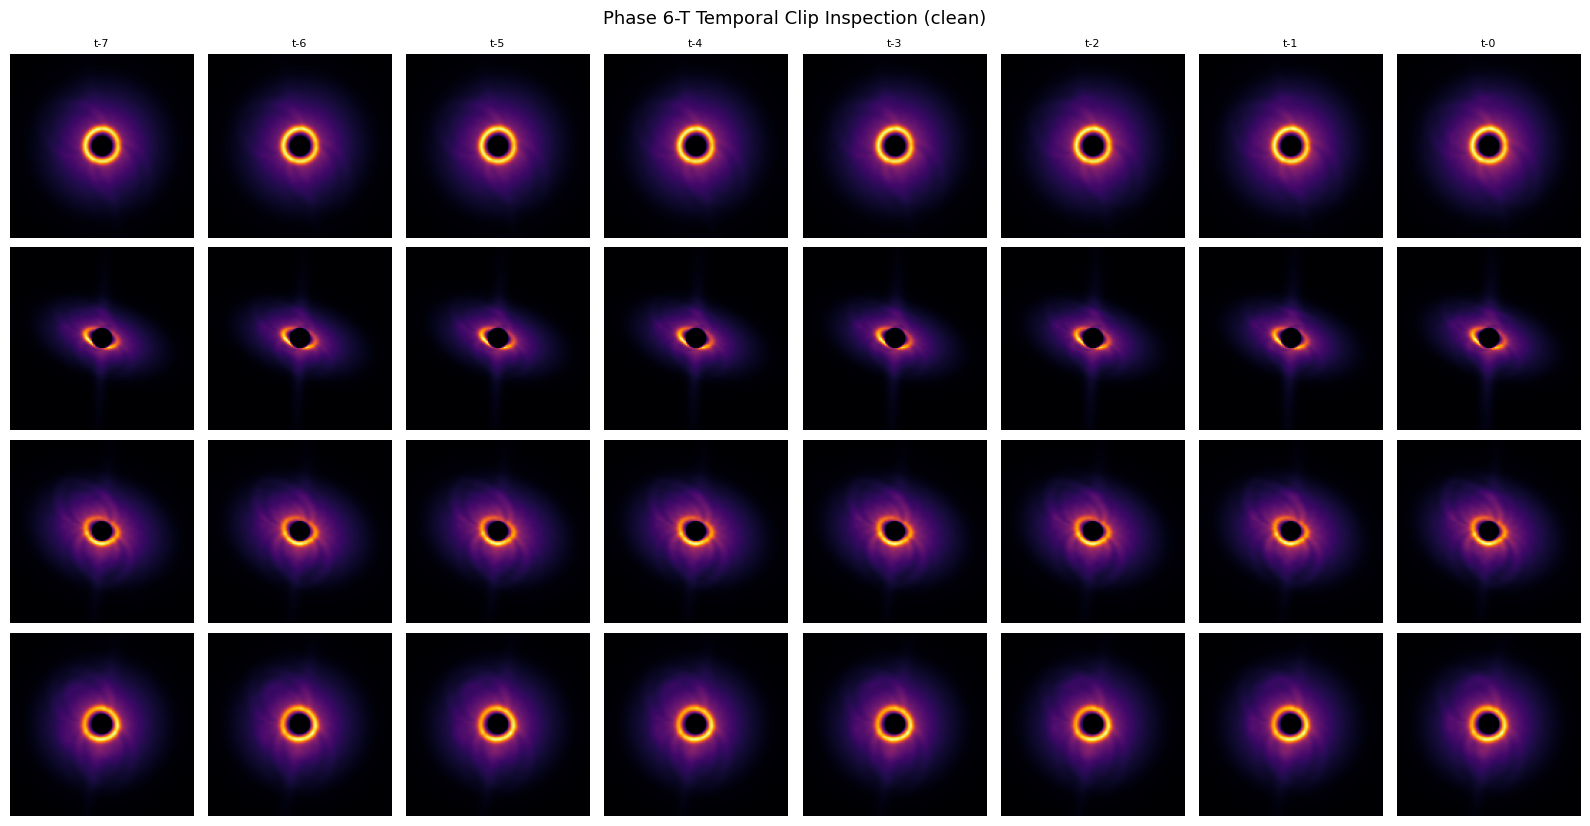

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_clip_visual_inspection_clean.png


In [8]:
# ================================================================
# 8. Visual inspection of temporal clips
# ================================================================

inspect_cases = []
for event_type in EVENT_TYPES:
    sub = phase6t_params_df[phase6t_params_df["event_type"] == event_type]
    inspect_cases.append(sub.iloc[0])

fig, axes = plt.subplots(len(inspect_cases), CLIP_LENGTH, figsize=(2.0 * CLIP_LENGTH, 2.1 * len(inspect_cases)))
if len(inspect_cases) == 1:
    axes = np.array([axes])

for row_idx, row in enumerate(inspect_cases):
    sid = str(row["sample_id"])
    clip_path = DATASET_DIR / ("clips_clean" if INPUT_MODE == "clean" else "clips_noisy") / (f"{sid}.npz" if INPUT_MODE == "clean" else f"{sid}_noisy.npz")
    clip = load_npz_clip(clip_path)
    for t in range(CLIP_LENGTH):
        ax = axes[row_idx, t]
        ax.imshow(clip[t], cmap="inferno", vmin=0, vmax=1)
        ax.axis("off")
        if t == 0:
            ax.set_ylabel(f"{row['event_type']}\nage={row['event_age']}", fontsize=8)
        if row_idx == 0:
            ax.set_title(f"t-{CLIP_LENGTH-1-t}", fontsize=8)

plt.suptitle(f"Phase 6-T Temporal Clip Inspection ({INPUT_MODE})", fontsize=13)
plt.tight_layout()
inspection_path = PHASE6T_DIR / f"phase6T_clip_visual_inspection_{INPUT_MODE}.png"
plt.savefig(inspection_path, dpi=150)
plt.show()

print("Saved:", inspection_path)

In [9]:
# ================================================================
# 9. Dataset class and loaders
# ================================================================

class Phase6TTemporalDataset(Dataset):
    def __init__(self, dataset_dir, input_mode="clean"):
        self.dataset_dir = Path(dataset_dir)
        self.input_mode = str(input_mode).lower().strip()
        self.params = pd.read_csv(self.dataset_dir / "params_table.csv")
        self.clean_dir = self.dataset_dir / "clips_clean"
        self.noisy_dir = self.dataset_dir / "clips_noisy"

        if self.input_mode not in ["clean", "noisy"]:
            raise ValueError(f"input_mode must be 'clean' or 'noisy', got {input_mode}")

    def __len__(self):
        return len(self.params)

    def _clip_path(self, sample_id):
        if self.input_mode == "clean":
            return self.clean_dir / f"{sample_id}.npz"
        return self.noisy_dir / f"{sample_id}_noisy.npz"

    def __getitem__(self, idx):
        row = self.params.iloc[idx]
        sample_id = str(row["sample_id"])
        clip = load_npz_clip(self._clip_path(sample_id))  # [T,H,W]
        clip = torch.from_numpy(clip).unsqueeze(1)         # [T,1,H,W]
        event_type = torch.tensor(int(row["event_type_index"]), dtype=torch.long)
        event_age = torch.tensor([float(row["event_age"]) / max(EVENT_AGES)], dtype=torch.float32)
        return clip, event_type, event_age, sample_id


temporal_dataset = Phase6TTemporalDataset(DATASET_DIR, input_mode=INPUT_MODE)

n_total = len(temporal_dataset)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    temporal_dataset,
    [n_train, n_val, n_test],
    generator=SPLIT_GENERATOR,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=LOADER_GENERATOR,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

clip, event_type, event_age, sid = temporal_dataset[0]
print("Dataset size:", len(temporal_dataset))
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
print("Example sample:", sid)
print("Clip shape:", clip.shape)
print("Event type:", event_type.item(), INDEX_TO_EVENT[event_type.item()])
print("Event age normalized:", event_age.item())

Dataset size: 1120
Train: 896 Val: 112 Test: 112
Example sample: p6_00001
Clip shape: torch.Size([8, 1, 128, 128])
Event type: 0 accretion_burst
Event age normalized: 0.0


In [10]:
# ================================================================
# 10. Temporal memory model: CNN frame encoder + GRU
# ================================================================

class FrameEncoder(nn.Module):
    def __init__(self, base=32, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base, 3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.SiLU(inplace=True),
            nn.Conv2d(base, base, 3, padding=1, bias=False),
            nn.BatchNorm2d(base),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(base, base * 2, 3, padding=1, bias=False),
            nn.BatchNorm2d(base * 2),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(base * 2, base * 4, 3, padding=1, bias=False),
            nn.BatchNorm2d(base * 4),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(base * 4, base * 8, 3, padding=1, bias=False),
            nn.BatchNorm2d(base * 8),
            nn.SiLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(base * 8, latent_dim),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Phase6TTemporalMemoryNet(nn.Module):
    def __init__(self, num_events=4, latent_dim=256, hidden_dim=256, dropout=0.20):
        super().__init__()
        self.encoder = FrameEncoder(base=32, latent_dim=latent_dim)
        self.gru = nn.GRU(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.type_head = nn.Linear(hidden_dim, num_events)
        self.age_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Sigmoid())

    def forward(self, clip):
        # clip: [B,T,1,H,W]
        B, T, C, H, W = clip.shape
        frames = clip.view(B * T, C, H, W)
        z = self.encoder(frames)
        z = z.view(B, T, -1)
        out, _ = self.gru(z)
        pooled = out.mean(dim=1)
        h = self.head(pooled)
        return self.type_head(h), self.age_head(h)


model = Phase6TTemporalMemoryNet(num_events=len(EVENT_TYPES)).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 1,385,509


In [11]:
# ================================================================
# 11. Training utilities
# ================================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)


def compute_loss(logits, pred_age, true_type, true_age):
    type_loss = F.cross_entropy(logits, true_type)
    age_loss = F.smooth_l1_loss(pred_age, true_age)
    loss = TYPE_LOSS_WEIGHT * type_loss + AGE_LOSS_WEIGHT * age_loss
    return loss, type_loss, age_loss


def r2_score_np(pred, true):
    pred = np.asarray(pred).reshape(-1)
    true = np.asarray(true).reshape(-1)
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2) + 1e-8
    return float(1.0 - ss_res / ss_tot)


def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    for clip, event_type, event_age, _ in loader:
        clip = clip.to(DEVICE, non_blocking=True)
        event_type = event_type.to(DEVICE, non_blocking=True)
        event_age = event_age.to(DEVICE, non_blocking=True)

        logits, pred_age = model(clip)
        loss, _, _ = compute_loss(logits, pred_age, event_type, event_age)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * clip.size(0)

    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, type_losses, age_losses = [], [], []
    all_sids, true_types, pred_types, true_ages, pred_ages = [], [], [], [], []

    for clip, event_type, event_age, sample_ids in loader:
        clip = clip.to(DEVICE, non_blocking=True)
        event_type = event_type.to(DEVICE, non_blocking=True)
        event_age = event_age.to(DEVICE, non_blocking=True)

        logits, pred_age = model(clip)
        loss, type_loss, age_loss = compute_loss(logits, pred_age, event_type, event_age)
        pred_type = logits.argmax(dim=1)

        losses.append(loss.item())
        type_losses.append(type_loss.item())
        age_losses.append(age_loss.item())

        all_sids.extend(list(sample_ids))
        true_types.extend(event_type.cpu().numpy().tolist())
        pred_types.extend(pred_type.cpu().numpy().tolist())
        true_ages.extend((event_age.cpu().numpy().reshape(-1) * max(EVENT_AGES)).tolist())
        pred_ages.extend((pred_age.cpu().numpy().reshape(-1) * max(EVENT_AGES)).tolist())

    true_ages_np = np.array(true_ages)
    pred_ages_np = np.array(pred_ages)
    true_types_np = np.array(true_types)
    pred_types_np = np.array(pred_types)

    return {
        "loss": float(np.mean(losses)),
        "type_loss": float(np.mean(type_losses)),
        "age_loss": float(np.mean(age_losses)),
        "type_accuracy": float(np.mean(true_types_np == pred_types_np)),
        "age_mae": float(np.mean(np.abs(true_ages_np - pred_ages_np))),
        "age_r2": r2_score_np(pred_ages_np, true_ages_np),
        "sample_ids": all_sids,
        "true_type": true_types,
        "pred_type": pred_types,
        "true_age": true_ages,
        "pred_age": pred_ages,
    }

In [12]:
# ================================================================
# 12. Train temporal model
# ================================================================

best_val_loss = float("inf")
patience = 0
history = []

best_model_path = PHASE6T_DIR / f"best_phase6T_temporal_model_{INPUT_MODE}_clip{CLIP_LENGTH}.pt"
history_path = PHASE6T_DIR / f"phase6T_training_history_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"

print("=" * 70)
print("Phase 6-T Training")
print("=" * 70)
print("Input mode:", INPUT_MODE)
print("Clip length:", CLIP_LENGTH)
print("Best model path:", best_model_path)
print("History path:", history_path)
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader)
    val_metrics = evaluate(model, val_loader)
    scheduler.step(val_metrics["loss"])
    lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_loss": float(val_metrics["loss"]),
        "val_type_loss": float(val_metrics["type_loss"]),
        "val_age_loss": float(val_metrics["age_loss"]),
        "val_type_accuracy": float(val_metrics["type_accuracy"]),
        "val_age_mae": float(val_metrics["age_mae"]),
        "val_age_r2": float(val_metrics["age_r2"]),
        "lr": float(lr),
    }
    history.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = float(val_metrics["loss"])
        patience = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_loss": best_val_loss,
                "input_mode": INPUT_MODE,
                "clip_length": CLIP_LENGTH,
                "clip_stride": CLIP_STRIDE,
                "event_types": EVENT_TYPES,
                "event_ages": EVENT_AGES,
                "seed": SEED,
                "config": {
                    "batch_size": BATCH_SIZE,
                    "num_epochs": NUM_EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "type_loss_weight": TYPE_LOSS_WEIGHT,
                    "age_loss_weight": AGE_LOSS_WEIGHT,
                    "deterministic_algorithms": DETERMINISTIC_ALGORITHMS,
                },
            },
            best_model_path,
        )
        best_flag = " <-- best"
    else:
        patience += 1
        best_flag = ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"train={train_loss:.5f} | "
        f"val={val_metrics['loss']:.5f} | "
        f"acc={val_metrics['type_accuracy']:.3f} | "
        f"age_MAE={val_metrics['age_mae']:.2f} | "
        f"age_R2={val_metrics['age_r2']:.3f} | "
        f"lr={lr:.2e}{best_flag}"
    )

    if patience >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.5f}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
print("Saved:", best_model_path)

Phase 6-T Training
Input mode: clean
Clip length: 8
Best model path: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/best_phase6T_temporal_model_clean_clip8.pt
History path: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_training_history_clean_clip8.csv
Epoch 001/45 | train=1.42916 | val=1.46053 | acc=0.223 | age_MAE=39.11 | age_R2=-0.039 | lr=5.00e-04 <-- best
Epoch 002/45 | train=1.42722 | val=1.43793 | acc=0.268 | age_MAE=38.59 | age_R2=-0.014 | lr=5.00e-04 <-- best
Epoch 003/45 | train=1.42274 | val=1.43100 | acc=0.286 | age_MAE=37.93 | age_R2=-0.001 | lr=5.00e-04 <-- best
Epoch 004/45 | train=1.41717 | val=1.44127 | acc=0.277 | age_MAE=35.79 | age_R2=0.036 | lr=5.00e-04
Epoch 005/45 | train=1.40688 | val=1.44212 | acc=0.205 | age_MAE=37.25 | age_R2=0.025 | lr=5.00e-04
Epoch 006/45 | train=1.39727 | val=1.55302 | acc=0.259 | age_MAE=35.84 | age_R2=-0.029 | lr=5.00e-04
Epoch 007/45 | train=1.4

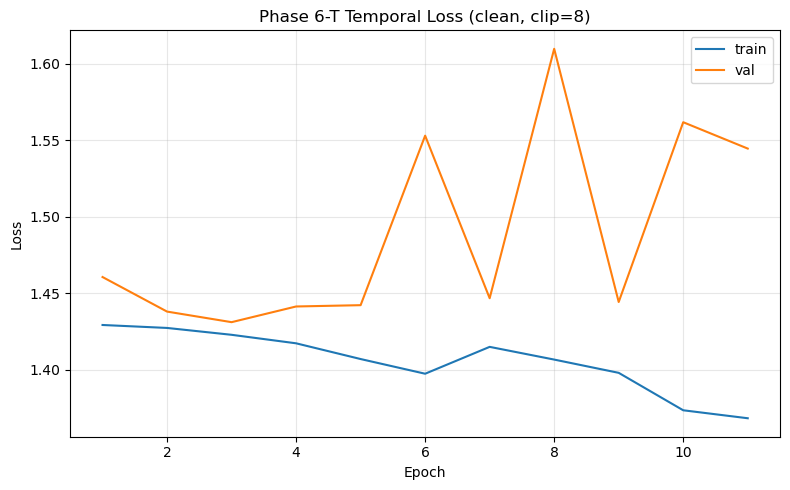

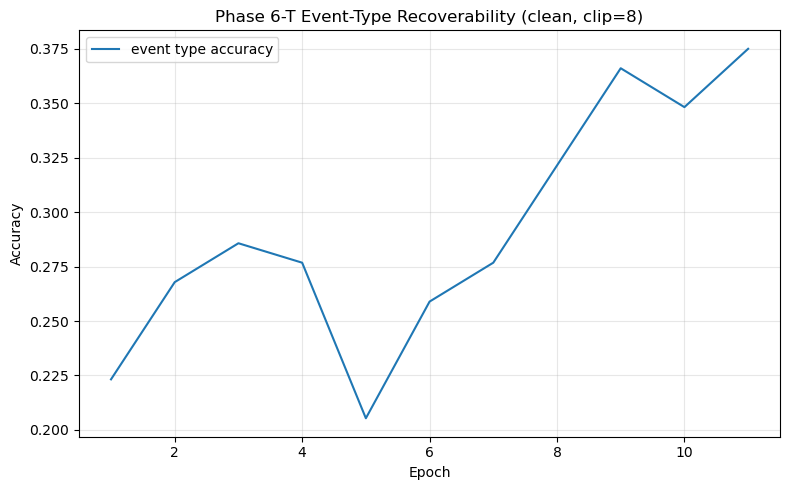

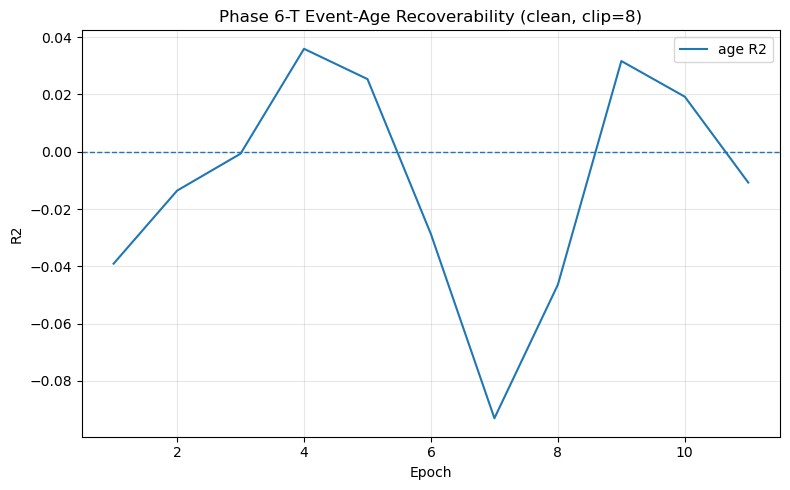

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_loss_curve_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_type_accuracy_curve_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_age_r2_curve_clean_clip8.png


In [13]:
# ================================================================
# 13. Training curves
# ================================================================

history_df = pd.DataFrame(history)
epochs = history_df["epoch"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["train_loss"].to_numpy(), label="train")
plt.plot(epochs, history_df["val_loss"].to_numpy(), label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Phase 6-T Temporal Loss ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
loss_plot_path = PHASE6T_DIR / f"phase6T_loss_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["val_type_accuracy"].to_numpy(), label="event type accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Phase 6-T Event-Type Recoverability ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
acc_plot_path = PHASE6T_DIR / f"phase6T_type_accuracy_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(acc_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_df["val_age_r2"].to_numpy(), label="age R2")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title(f"Phase 6-T Event-Age Recoverability ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
age_plot_path = PHASE6T_DIR / f"phase6T_age_r2_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(age_plot_path, dpi=150)
plt.show()

print("Saved:", loss_plot_path)
print("Saved:", acc_plot_path)
print("Saved:", age_plot_path)

In [14]:
# ================================================================
# 14. Test evaluation
# ================================================================

checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_metrics = evaluate(model, test_loader)

print("Test loss:", test_metrics["loss"])
print("Type accuracy:", test_metrics["type_accuracy"])
print("Age MAE frames:", test_metrics["age_mae"])
print("Age R2:", test_metrics["age_r2"])

pred_df = pd.DataFrame({
    "sample_id": test_metrics["sample_ids"],
    "true_type_index": test_metrics["true_type"],
    "pred_type_index": test_metrics["pred_type"],
    "true_age": test_metrics["true_age"],
    "pred_age": test_metrics["pred_age"],
})

pred_df["true_event_type"] = pred_df["true_type_index"].map(INDEX_TO_EVENT)
pred_df["pred_event_type"] = pred_df["pred_type_index"].map(INDEX_TO_EVENT)
pred_df["correct_type"] = pred_df["true_type_index"] == pred_df["pred_type_index"]
pred_df["age_abs_error"] = np.abs(pred_df["true_age"] - pred_df["pred_age"])
pred_df = pred_df.merge(phase6t_params_df, on="sample_id", how="left")

pred_path = PHASE6T_DIR / f"phase6T_test_predictions_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
pred_df.to_csv(pred_path, index=False)

metrics_path = PHASE6T_DIR / f"phase6T_test_metrics_{INPUT_MODE}_clip{CLIP_LENGTH}.json"
with open(metrics_path, "w") as f:
    json.dump({k: v for k, v in test_metrics.items() if k not in ["sample_ids", "true_type", "pred_type", "true_age", "pred_age"]}, f, indent=2)

display(pred_df.head())
print("Saved:", pred_path)
print("Saved:", metrics_path)

Test loss: 1.4208975553512573
Type accuracy: 0.3392857142857143
Age MAE frames: 37.34352561405727
Age R2: -0.01814366355153063


,sample_id,true_type_index,pred_type_index,true_age,pred_age,true_event_type,pred_event_type,correct_type,age_abs_error,mass,...,event_profile_recent,event_age,event_center,sample_index,event_type,event_type_index,clip_length,clip_stride,frame_start,frame_end
0,p6_00745,2,1,60.0,50.508259,turbulence_spike,jet_eruption,False,9.491741,8.836098,...,1.008745e-06,60,99,745,turbulence_spike,2,8,1,152,159
1,p6_00565,2,2,0.0,46.226723,turbulence_spike,turbulence_spike,True,46.226723,8.078439,...,4.518788e-01,0,159,565,turbulence_spike,2,8,1,152,159
2,p6_00400,1,2,20.0,45.673748,jet_eruption,turbulence_spike,False,25.673748,13.769351,...,3.036658e-01,20,139,400,jet_eruption,1,8,1,152,159
3,p6_00592,2,1,0.0,51.065372,turbulence_spike,jet_eruption,False,51.065372,9.473547,...,2.701721e-01,0,159,592,turbulence_spike,2,8,1,152,159
4,p6_00507,1,1,90.0,47.508816,jet_eruption,jet_eruption,True,42.491184,6.725646,...,4.205205e-20,90,69,507,jet_eruption,1,8,1,152,159


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_test_predictions_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_test_metrics_clean_clip8.json


,event_age,type_accuracy,age_mae,n
0,0.0,0.380952,49.785518,21
1,5.0,0.625000,46.104085,8
2,10.0,0.500000,40.499077,16
3,20.0,0.272727,28.372586,11
4,40.0,0.307692,9.695901,13
5,60.0,0.235294,8.918035,17
6,90.0,0.333333,39.813900,9
7,120.0,0.176471,68.946132,17


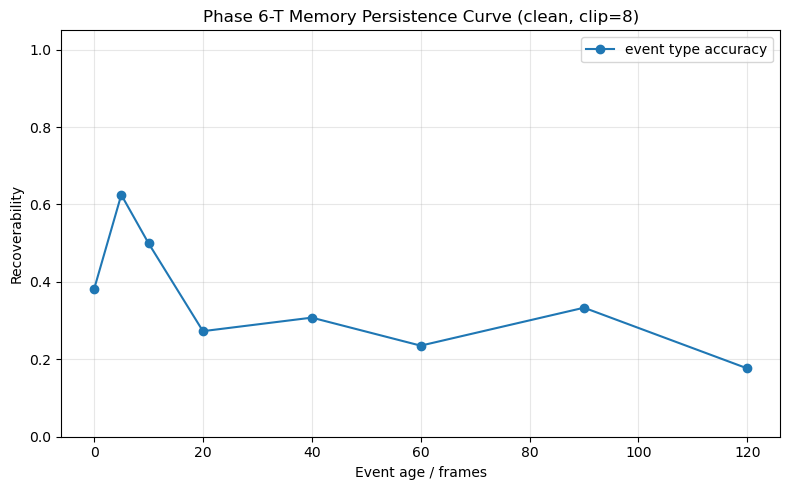

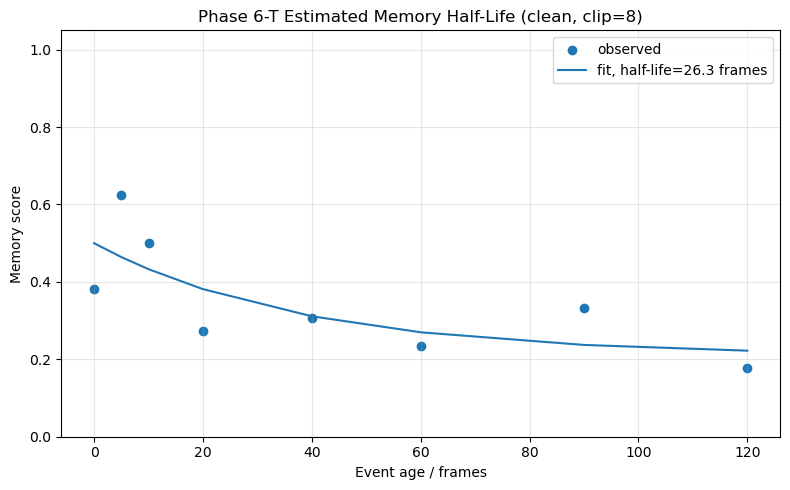

Memory half-life frames: 26.33959286127792
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_memory_curve_by_age_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_memory_persistence_curve_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_memory_half_life_fit_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_memory_half_life_summary_clean_clip8.json


In [15]:
# ================================================================
# 15. Memory persistence curves and half-life
# ================================================================

age_rows = []
for age in sorted(pred_df["event_age"].unique()):
    subset = pred_df[pred_df["event_age"] == age]
    age_rows.append({
        "event_age": float(age),
        "type_accuracy": float(subset["correct_type"].mean()),
        "age_mae": float(subset["age_abs_error"].mean()),
        "n": int(len(subset)),
    })

age_curve_df = pd.DataFrame(age_rows)
age_curve_path = PHASE6T_DIR / f"phase6T_memory_curve_by_age_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
age_curve_df.to_csv(age_curve_path, index=False)
display(age_curve_df)

plt.figure(figsize=(8, 5))
plt.plot(age_curve_df["event_age"].to_numpy(), age_curve_df["type_accuracy"].to_numpy(), marker="o", label="event type accuracy")
plt.xlabel("Event age / frames")
plt.ylabel("Recoverability")
plt.ylim(0, 1.05)
plt.title(f"Phase 6-T Memory Persistence Curve ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
memory_curve_plot_path = PHASE6T_DIR / f"phase6T_memory_persistence_curve_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(memory_curve_plot_path, dpi=150)
plt.show()

ages = age_curve_df["event_age"].to_numpy(dtype=np.float32)
scores = age_curve_df["type_accuracy"].to_numpy(dtype=np.float32)

best = None
for floor in np.linspace(0.0, 0.45, 46):
    for amp in np.linspace(0.05, 1.0, 96):
        for tau in np.linspace(5.0, 180.0, 176):
            fit = np.clip(floor + amp * np.exp(-ages / tau), 0.0, 1.0)
            mse = np.mean((scores - fit) ** 2)
            if best is None or mse < best[0]:
                best = (mse, floor, amp, tau)

fit_mse, fit_floor, fit_amp, fit_tau = best
memory_half_life = fit_tau * math.log(2.0)
fit_scores = np.clip(fit_floor + fit_amp * np.exp(-ages / fit_tau), 0.0, 1.0)

plt.figure(figsize=(8, 5))
plt.scatter(ages, scores, label="observed")
plt.plot(ages, fit_scores, label=f"fit, half-life={memory_half_life:.1f} frames")
plt.xlabel("Event age / frames")
plt.ylabel("Memory score")
plt.ylim(0, 1.05)
plt.title(f"Phase 6-T Estimated Memory Half-Life ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
halflife_plot_path = PHASE6T_DIR / f"phase6T_memory_half_life_fit_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(halflife_plot_path, dpi=150)
plt.show()

fit_summary = {
    "fit_floor": float(fit_floor),
    "fit_amplitude": float(fit_amp),
    "tau_frames": float(fit_tau),
    "memory_half_life_frames": float(memory_half_life),
    "fit_mse": float(fit_mse),
    "input_mode": INPUT_MODE,
    "clip_length": CLIP_LENGTH,
}

halflife_path = PHASE6T_DIR / f"phase6T_memory_half_life_summary_{INPUT_MODE}_clip{CLIP_LENGTH}.json"
with open(halflife_path, "w") as f:
    json.dump(fit_summary, f, indent=2)

print("Memory half-life frames:", memory_half_life)
print("Saved:", age_curve_path)
print("Saved:", memory_curve_plot_path)
print("Saved:", halflife_plot_path)
print("Saved:", halflife_path)

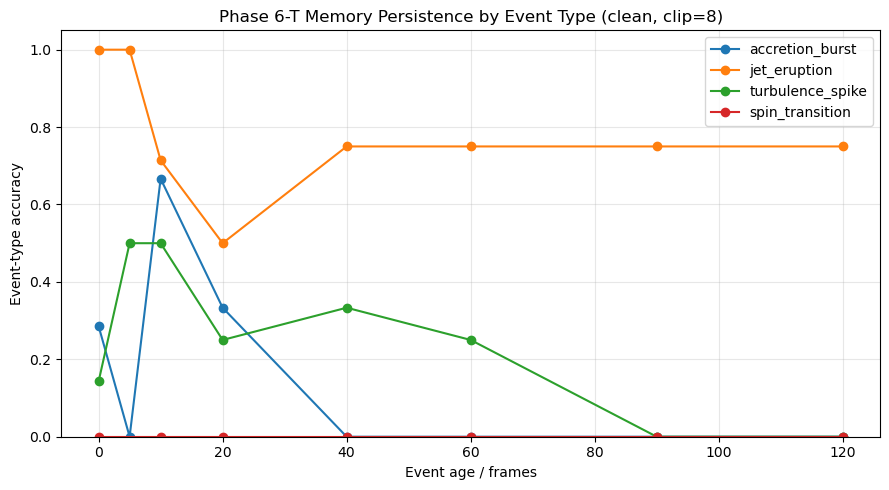

,accretion_burst,jet_eruption,turbulence_spike,spin_transition
accretion_burst,5,15,6,0
jet_eruption,3,27,4,0
turbulence_spike,1,22,6,0
spin_transition,3,12,8,0


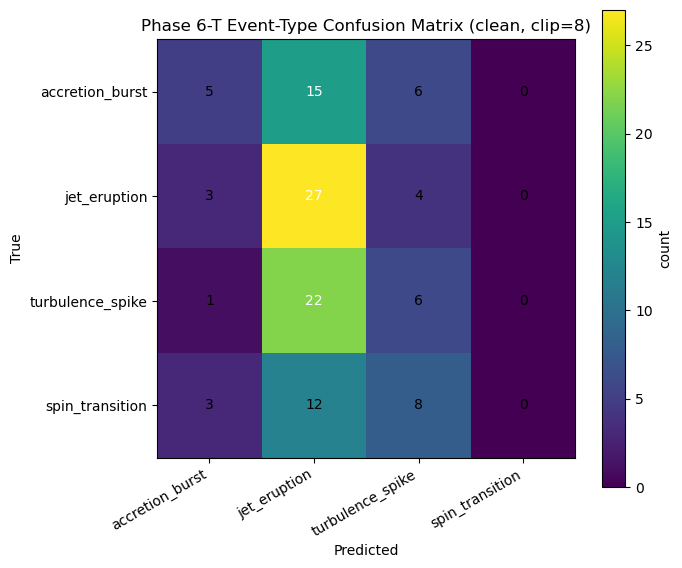

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_per_event_memory_curves_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_per_event_memory_curves_clean_clip8.png
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_event_confusion_matrix_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6T_event_confusion_matrix_clean_clip8.png


In [16]:
# ================================================================
# 16. Per-event curves and confusion matrix
# ================================================================

per_event_rows = []
for event_type in EVENT_TYPES:
    for age in sorted(pred_df["event_age"].unique()):
        subset = pred_df[(pred_df["true_event_type"] == event_type) & (pred_df["event_age"] == age)]
        if len(subset):
            per_event_rows.append({
                "event_type": event_type,
                "event_age": float(age),
                "type_accuracy": float(subset["correct_type"].mean()),
                "age_mae": float(subset["age_abs_error"].mean()),
                "n": int(len(subset)),
            })

per_event_df = pd.DataFrame(per_event_rows)
per_event_path = PHASE6T_DIR / f"phase6T_per_event_memory_curves_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
per_event_df.to_csv(per_event_path, index=False)

plt.figure(figsize=(9, 5))
for event_type in EVENT_TYPES:
    sub = per_event_df[per_event_df["event_type"] == event_type]
    plt.plot(sub["event_age"].to_numpy(), sub["type_accuracy"].to_numpy(), marker="o", label=event_type)
plt.xlabel("Event age / frames")
plt.ylabel("Event-type accuracy")
plt.ylim(0, 1.05)
plt.title(f"Phase 6-T Memory Persistence by Event Type ({INPUT_MODE}, clip={CLIP_LENGTH})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
per_event_plot_path = PHASE6T_DIR / f"phase6T_per_event_memory_curves_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(per_event_plot_path, dpi=150)
plt.show()

conf = np.zeros((len(EVENT_TYPES), len(EVENT_TYPES)), dtype=np.int32)
for t, p in zip(pred_df["true_type_index"], pred_df["pred_type_index"]):
    conf[int(t), int(p)] += 1

conf_df = pd.DataFrame(conf, index=EVENT_TYPES, columns=EVENT_TYPES)
conf_path = PHASE6T_DIR / f"phase6T_event_confusion_matrix_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
conf_df.to_csv(conf_path)
display(conf_df)

plt.figure(figsize=(7, 6))
plt.imshow(conf, cmap="viridis")
plt.xticks(np.arange(len(EVENT_TYPES)), EVENT_TYPES, rotation=30, ha="right")
plt.yticks(np.arange(len(EVENT_TYPES)), EVENT_TYPES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Phase 6-T Event-Type Confusion Matrix ({INPUT_MODE}, clip={CLIP_LENGTH})")
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        plt.text(j, i, str(conf[i, j]), ha="center", va="center", color="white" if conf[i, j] > conf.max()/2 else "black")
plt.colorbar(label="count")
plt.tight_layout()
conf_plot_path = PHASE6T_DIR / f"phase6T_event_confusion_matrix_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(conf_plot_path, dpi=150)
plt.show()

print("Saved:", per_event_path)
print("Saved:", per_event_plot_path)
print("Saved:", conf_path)
print("Saved:", conf_plot_path)

,observation,input_mode,clip_length,type_accuracy,age_mae,age_r2,memory_half_life
0,single_final_frame_phase6,clean,1,0.421875,31.779893,0.154620,60.996952
1,temporal_clip_phase6T,clean,8,0.339286,37.343526,-0.018144,26.339593


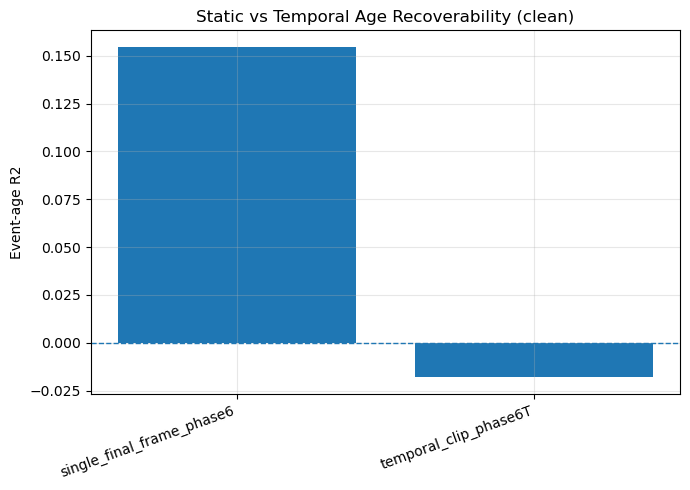

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6_vs_phase6T_comparison_clean_clip8.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase6T_temporal_memory_persistence/phase6_vs_phase6T_age_r2_clean_clip8.png


In [17]:
# ================================================================
# 17. Compare Phase 6 single-frame baseline vs Phase 6-T temporal model
# ================================================================

baseline_rows = []

phase6_metrics_path = PHASE6_DIR / f"phase6_test_metrics_{INPUT_MODE}.json"
phase6_half_path = PHASE6_DIR / f"phase6_memory_half_life_summary_{INPUT_MODE}.json"

if phase6_metrics_path.exists():
    with open(phase6_metrics_path, "r") as f:
        single_metrics = json.load(f)

    if phase6_half_path.exists():
        with open(phase6_half_path, "r") as f:
            single_half = json.load(f)
        single_half_life = single_half.get("memory_half_life_frames", np.nan)
    else:
        single_half_life = np.nan

    baseline_rows.append({
        "observation": "single_final_frame_phase6",
        "input_mode": INPUT_MODE,
        "clip_length": 1,
        "type_accuracy": single_metrics.get("type_accuracy", np.nan),
        "age_mae": single_metrics.get("age_mae", np.nan),
        "age_r2": single_metrics.get("age_r2", np.nan),
        "memory_half_life": single_half_life,
    })
else:
    print("Phase 6 baseline metrics not found:", phase6_metrics_path)

baseline_rows.append({
    "observation": "temporal_clip_phase6T",
    "input_mode": INPUT_MODE,
    "clip_length": CLIP_LENGTH,
    "type_accuracy": test_metrics["type_accuracy"],
    "age_mae": test_metrics["age_mae"],
    "age_r2": test_metrics["age_r2"],
    "memory_half_life": memory_half_life,
})

comparison_df = pd.DataFrame(baseline_rows)
comparison_path = PHASE6T_DIR / f"phase6_vs_phase6T_comparison_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
comparison_df.to_csv(comparison_path, index=False)
display(comparison_df)

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["observation"], comparison_df["age_r2"])
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.ylabel("Event-age R2")
plt.title(f"Static vs Temporal Age Recoverability ({INPUT_MODE})")
plt.xticks(rotation=20, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
comparison_plot_path = PHASE6T_DIR / f"phase6_vs_phase6T_age_r2_{INPUT_MODE}_clip{CLIP_LENGTH}.png"
plt.savefig(comparison_plot_path, dpi=150)
plt.show()

print("Saved:", comparison_path)
print("Saved:", comparison_plot_path)

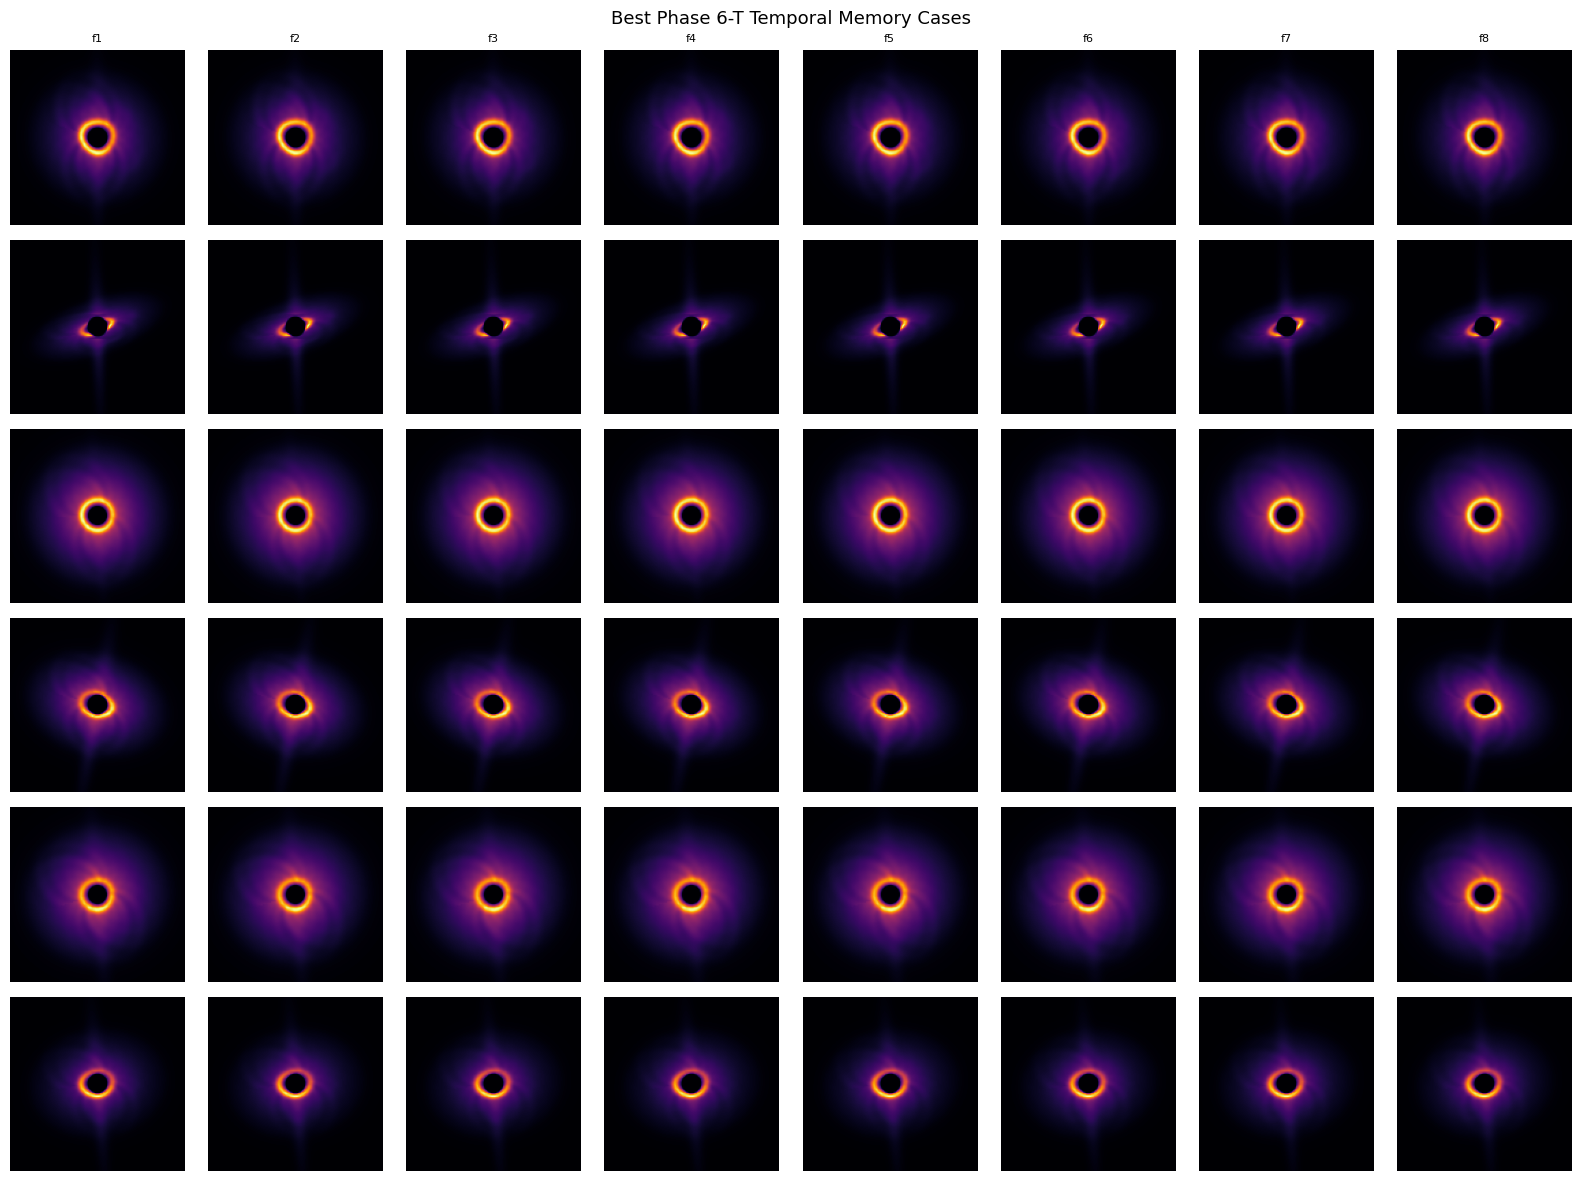

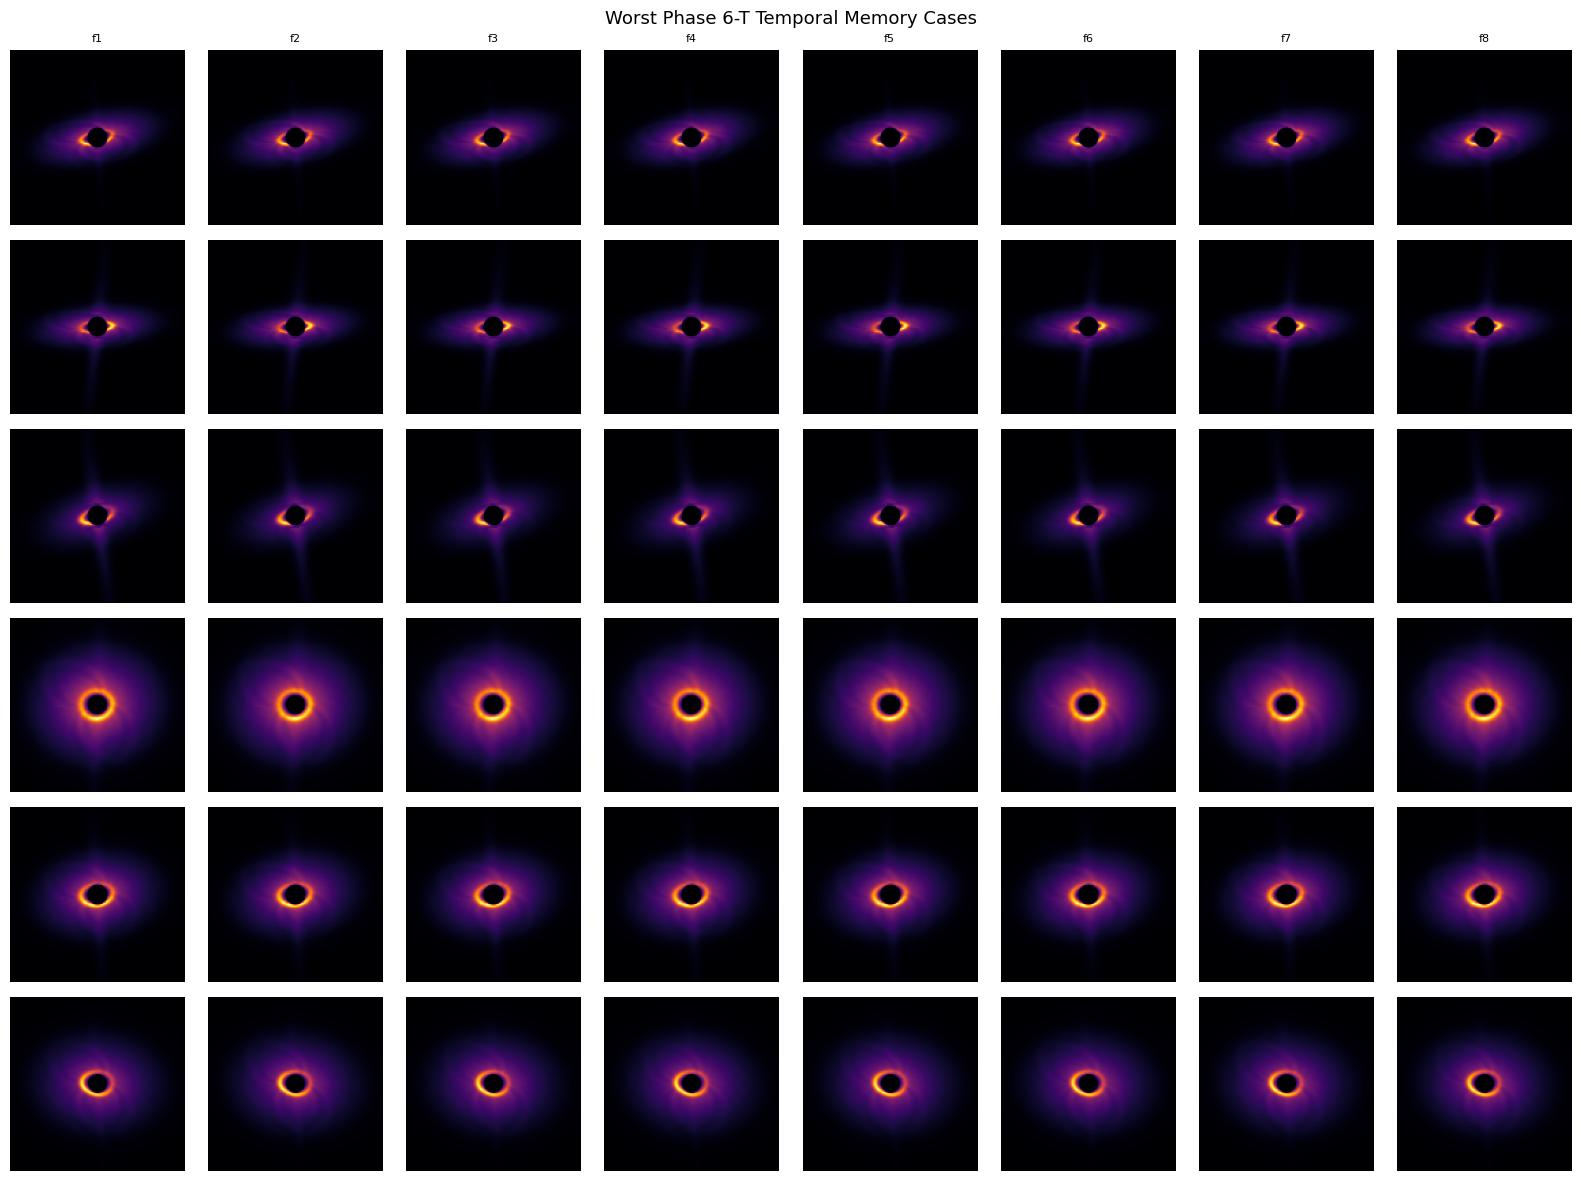


Phase 6-T Summary — Temporal Memory Persistence

Dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6T_temporal_memory_persistence

Source Phase 6 dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase6_memory_persistence

Simulator source:
  /home/marwa/files/phase1_blackhole_generator/physics_blackhole_demo.py

Simulator SHA256:
  41e00c206e5f47711d06305ba4aff5aaa65802f846682288c5f5d78aa1a2ac2a

Input mode:
  clean

Clip length:
  8

Clip stride:
  1

Events:
  ['accretion_burst', 'jet_eruption', 'turbulence_spike', 'spin_transition']

Event ages:
  [0, 5, 10, 20, 40, 60, 90, 120]

Samples:
  1120

Test performance:
  Event-type accuracy = 0.33929
  Event-age MAE       = 37.344 frames
  Event-age R2        = -0.01814

Estimated memory half-life:
  26.340 frames

Interpretation:
  Phase 6-T tests whether short temporal observations preserve more information
  than a single final frame. If the temporal clip improves event-age R2 or reduces
  

In [18]:
# ================================================================
# 18. Best/worst temporal examples and final summary
# ================================================================

best_cases = pred_df.sort_values(["correct_type", "age_abs_error"], ascending=[False, True]).head(6)
worst_cases = pred_df.sort_values(["correct_type", "age_abs_error"], ascending=[True, False]).head(6)

best_worst_path = PHASE6T_DIR / f"phase6T_best_worst_cases_{INPUT_MODE}_clip{CLIP_LENGTH}.csv"
pd.concat([
    best_cases.assign(group="best"),
    worst_cases.assign(group="worst"),
]).to_csv(best_worst_path, index=False)


def clip_path_for_case(sample_id, input_mode):
    if input_mode == "clean":
        return DATASET_DIR / "clips_clean" / f"{sample_id}.npz"
    if input_mode == "noisy":
        return DATASET_DIR / "clips_noisy" / f"{sample_id}_noisy.npz"
    raise ValueError(input_mode)


def show_temporal_cases(case_df, title, n=6):
    case_df = case_df.head(n).copy()
    if len(case_df) == 0:
        print("No cases to show.")
        return

    fig, axes = plt.subplots(len(case_df), CLIP_LENGTH, figsize=(2.0 * CLIP_LENGTH, 2.0 * len(case_df)))
    if len(case_df) == 1:
        axes = np.array([axes])

    for row_idx, (_, row) in enumerate(case_df.iterrows()):
        sid = str(row["sample_id"])
        clip = load_npz_clip(clip_path_for_case(sid, INPUT_MODE))
        for t in range(CLIP_LENGTH):
            ax = axes[row_idx, t]
            ax.imshow(clip[t], cmap="inferno", vmin=0, vmax=1)
            ax.axis("off")
            if t == 0:
                ax.set_ylabel(
                    f"{sid}\nT:{row['true_event_type']}\nP:{row['pred_event_type']}\nage={row['event_age']:.0f}\npred={row['pred_age']:.1f}",
                    fontsize=7,
                )
            if row_idx == 0:
                ax.set_title(f"f{t+1}", fontsize=8)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


show_temporal_cases(best_cases, "Best Phase 6-T Temporal Memory Cases")
show_temporal_cases(worst_cases, "Worst Phase 6-T Temporal Memory Cases")

summary_text = f"""
Phase 6-T Summary — Temporal Memory Persistence
===============================================

Dataset:
  {DATASET_DIR}

Source Phase 6 dataset:
  {PHASE6_DATASET_DIR}

Simulator source:
  {GPU_SIMULATOR_PATH}

Simulator SHA256:
  {simulator_sha256}

Input mode:
  {INPUT_MODE}

Clip length:
  {CLIP_LENGTH}

Clip stride:
  {CLIP_STRIDE}

Events:
  {EVENT_TYPES}

Event ages:
  {EVENT_AGES}

Samples:
  {len(phase6t_params_df)}

Test performance:
  Event-type accuracy = {test_metrics['type_accuracy']:.5f}
  Event-age MAE       = {test_metrics['age_mae']:.3f} frames
  Event-age R2        = {test_metrics['age_r2']:.5f}

Estimated memory half-life:
  {memory_half_life:.3f} frames

Interpretation:
  Phase 6-T tests whether short temporal observations preserve more information
  than a single final frame. If the temporal clip improves event-age R2 or reduces
  age MAE relative to Phase 6, then time-domain observation provides additional
  recoverable memory information.

Recommended next step:
  Run this notebook with INPUT_MODE='clean' and INPUT_MODE='noisy'. Then repeat
  with CLIP_LENGTH=16 to test whether longer monitoring improves memory recovery.
"""

summary_path = PHASE6T_DIR / f"phase6T_summary_{INPUT_MODE}_clip{CLIP_LENGTH}.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", best_worst_path)
print("Saved:", summary_path)

## Final conclusion

Use Phase 6 as the static baseline and Phase 6-T as the temporal observation experiment.

The key thesis/paper figure is the comparison:

```text
single final frame vs temporal clip
```

for:

```text
event-type accuracy
event-age R2
event-age MAE
memory half-life
```

If Phase 6-T improves age recovery, the study gains a stronger conclusion:

> Black-hole memory is not only encoded in final morphology; it becomes more recoverable when the observer samples temporal evolution.